# Decision Tree  
A decision tree is a supervised learning algorithm used for both classification and regression tasks. It has a hierarchical tree structure which consists of a root node, branches, internal nodes and leaf nodes. It works like a flowchart that helps in making step-by-step decisions.  

A decision tree splits the dataset based on feature values to create pure subsets ideally all items in a group belong to the same class. Each leaf node represents the final output, which can be a class label (in classification) or a continuous value (in regression).  
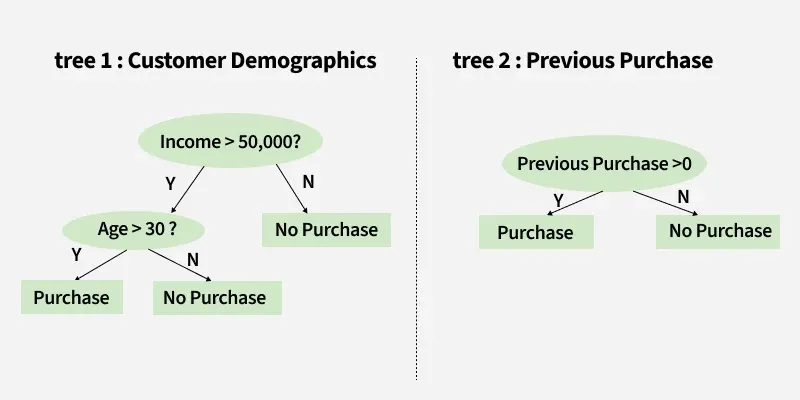  
A decision tree makes predictions using a single tree structure by following decision paths from root to leaf.
Tree 1: Customer Demographics  
First tree asks two questions:    
1."Income > $50,000?"  
If Yes, Proceed to the next question.  
If No, "No Purchase"   

2."Age > 30?"  
Yes: "Purchase"  
No: "No Purchase"  

Tree 2: Previous Purchases   
"Previous Purchases > 0?"  
Yes: "Purchase"  
No: "No Purchase"  

Once we have predictions from both trees, we can combine the results to make a final prediction. If Tree 1 predicts "Purchase" and Tree 2 predicts "No Purchase", the final prediction might be "Purchase" or "No Purchase" depending on the weight or confidence assigned to each tree. This can be decided based on the problem context.  

Decision Tree for regression:  
For regression, the tree predicts a continuous value, such as house price.  
Regression trees commonly use MSE (Mean Squared Error) to determine splits.

**Advantages:**   
Easy to understand and visualize  
Requires little data preprocessing  
Can handle nonlinear relationships  
Can handle both numerical and categorical features  
No need for feature scaling  

**Disadvantages**  
Can easily overfit  
Small changes in data can produce a very different tree  
A very deep tree becomes difficult to interpret    

### Recursive Binary Splitting  
Recursive binary splitting is a top-down, greedy algorithm used to build decision trees by successively dividing a dataset into two sub-regions. It starts with all data in one group, makes the best local split at each step, and repeats the process on new subgroups. It will continue splitting until it gets the pure leaf node.  
It is called as greedy algorithm because it continues to split without thinking about what going to happen next.  

How the Algorithm WorksTop-Down:  
The process begins at the root node with all observations in a single set.  
Binary: Every single step splits a group into exactly two smaller parts.  
Greedy: The code picks the best split available right now. It does not plan ahead for future steps.  
Recursive: The same splitting rule applies over and over to each new child group until a stop rule is met  

It increases variance which lead to overfitting .  

For a classification tree, the "best" split is commonly selected using Gini impurity or entropy/information gain.  
For a regression tree, it is commonly selected using MSE (Mean Squared Error).  


## Tree Purning  
Tree pruning is a machine learning optimization technique used to reduce the size of a decision tree by removing sections that provide little predictive power. Decision trees are highly prone to overfitting because they grow recursively until they perfectly split and memorize noise in the training data. Pruning resolves this issue by strategically cutting back weak or redundant branches, shifting the focus from data memorization to learning generalizable patterns.  
Just like linear regression we can regularise the decision tree by adding new term.

Types:

**1. Pre purning**:
Pre-pruning is also known as for, is a pruning strategy in which the growth of the decision tree is restricted during the training phase itself. Instead of allowing the tree to grow fully and then trimming it later, pre-pruning prevents certain splits from being created if they do not satisfy predefined constraints.

Controls tree complexity during training  
Prevents unnecessary splits early in the learning process    
Produces compact and shallow trees  
Reduces training time and memory usage  

Working:  
The decision tree starts growing from the root node using training data  
At each node, the algorithm checks whether a split satisfies predefined conditions  
If the split improves impurity reduction and meets constraints, the node is split  
If the split does not meet conditions, the node is converted into a leaf  
Constraints such as maximum depth or minimum samples control further growth  
Tree growth stops early before it becomes overly complex  
The final tree remains shallow and simple  

**2. Post purning**:  
Post-pruning is a pruning strategy in which the decision tree is allowed to grow to its full depth first, after which unnecessary or weak branches are removed. Unlike pre-pruning, this approach does not restrict the tree during training. Instead, it analyzes the fully grown tree and evaluates whether certain subtrees contribute meaningfully to predictive performance.  
  
Applied after the tree is fully grown  
Uses validation or test performance for pruning decisions  
Produces well-balanced trees with better generalization  
Typically results in higher predictive stability  

Working  
The decision tree is first grown completely using the training dataset    
All possible splits are created without restricting tree depth  
The fully grown tree is then evaluated using validation or test data  
Branches that do not improve prediction accuracy are identified  
Weak or unnecessary subtrees are removed from the tree  
Removed branches are replaced with leaf nodes  
The final tree is simpler while maintaining strong generalization performance  



Entropy, information gain, gini impurity are used on what bases does the tree split should happen.  
### Entropy: 
Entropy is a critical measure used to evaluate the impurity or randomness within a dataset. By understanding and calculating entropy, you can determine how to split data into more homogenous subsets, ultimately building a better decision tree that leads to accurate predictions.
Entropy helps in choosing which feature to split on at each decision node in the tree. Goal is to reduce entropy with each split to create subsets that are as pure as possible
A region is said to be clean(low entropy) if it contains data with same labels and random if there is a mixture of labels present(High entropy).  
Let suppose we have 'm' observations and we need to classify them into two categories 1 and 2. Let's say that category 1 has'n' observations and category 2 has 'm-n' observaions.  
p= n/m and q= m-n/m = 1-p

Then entropy is given by: 
$$
Entropy = -p\log_2(p) - q\log_2(q)
$$

### Information Gain:  
Information Gain (IG) measures the reduction in uncertainty or randomness (entropy) achieved by splitting a dataset based on a specific feature.In machine learning, decision tree algorithms like ID3 and C4.5 calculate Information Gain at each node to determine the optimal attribute for partitioning data. The feature yielding the highest Information Gain is chosen as the splitting criterion for that node.  
Information Gain (IG) tells us how much a split reduces the impurity (entropy) of the data.  

IG = Entropy(parent) - Weighted Entropy(children)
$$
IG = E(parent) - ((n_1/n) * E(child_1) + (n_2/n) * E(child_2))  
$$

### Gini Impurity:  
Gini impurity is a metric used by classification decision tree algorithms (like CART) to measure the probability of a randomly chosen element being incorrectly labeled if it were randomly classified according to the distribution of labels in the node. The primary goal of a decision tree is to split data into the "purest" possible child nodes, and it uses Gini impurity to evaluate which feature provides the best split.  
The mathematical formula for calculating Gini impurity (G) for a given node is:  
$$
Gini = 1 - \sum_{i=1}^{n} p_i^2
$$
Where:  
n is the total number of classes in the dataset.  
pi is the probability or proportion of data points belonging to class i in that node.    

How Decision Trees Use Gini Impurity:  
When building a tree, the algorithm evaluates every possible feature split using these steps:  
1)Calculate Parent Impurity: Find the Gini impurity of the current node before making any split.  
2)Compute Child Impurity: For a given feature split, calculate the Gini impurity of each resulting child node.  
3)Calculate Weighted Gini: Combine the child impurities into a weighted average based on the number of samples that went into each child node.  
4)Maximize Gini Gain: Choose the split condition that results in the lowest weighted Gini impurity for the child nodes (which maximizes the drop in impurity from the parent).  

Step-by-Step Calculation Example:

Suppose a node contains 10 data points:

- 6 belong to Class A ("Apple")
- 4 belong to Class B ("Orange")

1. Find probabilities

$$
p_{\text{Class A}} = \frac{6}{10} = 0.6
$$

$$
p_{\text{Class B}} = \frac{4}{10} = 0.4
$$

2. Apply the Gini Impurity Formula

$$
G = 1 - \sum_{i=1}^{n} p_i^2
$$

For two classes:

$$
G = 1 - (p_{\text{Class A}}^2 + p_{\text{Class B}}^2)
$$

Substitute the values:

$$
G = 1 - (0.6^2 + 0.4^2)
$$

$$
G = 1 - (0.36 + 0.16)
$$

$$
G = 1 - 0.52
$$

$$
\boxed{G = 0.48}
$$

Conclusion

The **Gini Impurity = 0.48**.

This indicates that the node contains a **mix of Class A and Class B data points**.  
Because Gini impurity avoids complex logarithmic math, it is computationally faster and highly efficient for training large-scale datasets. 

### Different Algorithms for Decision tree:
Core Decision Tree Algorithms:

**ID3 (Iterative Dichotomiser 3)**: This classification-only algorithm creates multi-way branches. It uses Information Gain (derived from Entropy) to choose features. It only supports nominal/categorical data and lacks a mechanism for pruning, making it highly prone to overfitting.

**C4.5**: The direct successor to ID3, C4.5 addresses its predecessor's flaws by accepting both continuous and categorical variables. It replaces Information Gain with the Gain Ratio to reduce bias toward features with many distinct values. It handles missing data and employs post-pruning to trim useless branches.

**CART (Classification and Regression Trees)**: A versatile algorithm that generates strictly binary trees (each node splits into exactly two branches). For classification tasks, it utilizes Gini Impurity to evaluate splits. For regression tasks, it minimizes variance or Mean Squared Error (MSE). This is the algorithm implemented in popular frameworks like scikit-learn.

## Cross Validation  
Cross-validation is a data testing method used in machine learning to check how well a model predicts new, unseen data. It splits the data into parts, trains the model on some parts, and tests it on the leftover parts, repeating this process to find the true error rate and stop overfitting.  

### Hold Out Method:
Hold-out cross-validation (or the hold-out method) is a model evaluation technique where a dataset is split into completely distinct subsets to train and test a machine learning model. Unlike iterative cross-validation techniques like K-Fold, the hold-out method performs a single, static split of the data rather than rotating through multiple combinations.  

Training set → used to train the model  
Validation/Test set → used to evaluate the model  

Usually we split into 80 - 20.  
80% data for training and 20% data for testing.  

Suppose we have 1000 data points:
when we split into 80-20, 800 data points will assigned to training and 200 data points are assigned to testing.

### K-Fold Cross Validation:
K-fold cross-validation is a technique used to evaluate machine learning models. It splits data into k equal parts. The model trains on k-1 parts and tests on the remaining part. This repeats k times so every part gets tested once. Scores are then averaged for a reliable performance estimate.  

How the Process Works:  
Shuffle data: Mix the dataset randomly to avoid any order bias.  
Split into k parts: Divide the data into k equal-sized subsets or "folds". Standard choices for k are 5 or 10.  
Train and test: Use k-1 folds for training the model and 1 fold for testing.  
Repeat: Rotate the test fold k times until every fold has been used as the test set.  
Average scores: Combine all k evaluation scores to find the mean performance metric  

Suppose we have 100 data points and choose: K = 5  

So the dataset is divided into 5 folds:  

Iteration 1:  
Training: Fold 2 + Fold 3 + Fold 4 + Fold 5  
Testing:  Fold 1  

Iteration 2  
Training: Fold 1 + Fold 3 + Fold 4 + Fold 5    
Testing:  Fold 2  

Iteration 3  
Training: Fold 1 + Fold 2 + Fold 4 + Fold 5  
Testing:  Fold 3  

Iteration 4  
Training: Fold 1 + Fold 2 + Fold 3 + Fold 5  
Testing:  Fold 4  

Iteration 5  
Training: Fold 1 + Fold 2 + Fold 3 + Fold 4   
Testing:  Fold 5  

$$
Score = \frac{1}{K}\sum_{i=1}^{K} Score_i
$$

### Leave One Out Cross Validation  
Leave-one-out cross-validation (LOOCV) is a model evaluation method where a machine learning algorithm is trained on all data points except one, which is reserved for testing. This process repeats N times (where N is the total number of samples) so every data point acts as a test case once.  

How LOOCV Works:  
Set N as the total number of samples in the dataset.  
Train the model using N - 1 samples.  
Test the model on the single excluded data point and record the error.  
Repeat the cycle N times until every sample has been left out once.  
Calculate the final performance score by averaging the errors from all N evaluations.  

High Variance, low bias and Computationally Expensive.  

Suppose you have 5 data points:  
A, B, C, D, E  
LOOCV performs 5 iterations.  
Iteration 1:  
Training → B C D E    
Testing  → A  

Iteration 2:  
Training → A C D E  
Testing  → B  

Iteration 3:  
Training → A B D E  
Testing  → C  

Iteration 4:  
Training → A B C E  
Testing  → D  

Iteration 5:  
Training → A B C D  
Testing  → E  

$$
LOOCV\ Score = \frac{1}{n}\sum_{i=1}^{n} Score_i
$$


### Stratified cross-validation  
Stratified cross-validation is a technique used to test machine learning classification models. It makes sure that every subset (or fold) of data contains the exact same percentage of each class label as the total dataset. This prevents random splits from leaving out rare classes in training or test sets.  
Stratified Cross-Validation does not change the model. It only changes how the data is divided into training and validation folds. 
Stratified K-Fold = K-Fold Cross-Validation + preservation of class distribution.  

Why Use It:  
Fixes problems with uneven or rare data groups.  
Stops models from learning bad patterns due to missing labels.  
Gives a much truer score of how well a model works  

How It Works:  
Counts the items in each target class.  
Splits each class evenly into K parts.  
Builds each fold by combining these equal parts.  
Trains on K-1 folds and tests on the last fold.  
Repeats K times until every fold is used for testing  



## Hyperparameter Tuning  
A hyperparameter is a setting that you choose before training the model.  
Hyperparameter tuning is the process of selecting the optimal values for a machine learning model's hyperparameters. These are typically set before the actual training process begins and control aspects of the learning process itself. Effective tuning helps the model learn better patterns, avoid overfitting or underfitting and achieve higher accuracy on unseen data.  
For a Decision Tree, examples are:  

max_depth   
min_samples_split  
min_samples_leaf  
criterion  
ccp_alpha  

Models can have many hyperparameters and finding the best combination of parameters can be treated as a search problem. The two best strategies for Hyperparameter tuning are:  

**1)GridSearchCV** :  GridSearchCV is a brute-force technique for hyperparameter tuning. It trains the model using all possible combinations of specified hyperparameter values to find the best-performing setup. It is slow and uses a lot of computer power which makes it hard to use with big datasets or many settings. It works using below steps:  

Create a grid of potential values for each hyperparameter.  
Train the model for every combination in the grid.  
Evaluate each model using cross-validation.  
Select the combination that gives the highest score.  

The following code illustrates how to use GridSearchCV . In this below code:  

We generate sample data using make_classification.   
We define a range of C values using logarithmic scale.  
GridSearchCV tries all combinations from param_grid and uses 5-fold cross-validation.  
It returns the best hyperparameter (C) and its corresponding validation score.  

**2)RandomizedSearchCV**:As the name suggests RandomizedSearchCV picks random combinations of hyperparameters from the given ranges instead of checking every single combination like GridSearchCV.  

In each iteration it tries a new random combination of hyperparameter values.   
It records the model’s performance for each combination.  
After several attempts it selects the best-performing set.  

The following code illustrates how to use RandomizedSearchCV. In this example:  

We define a range of values for each hyperparameter e.g, max_depth, min_samples_leaf etc.  
Random combinations are picked and evaluated using 5-fold cross-validation.  
The best combination and score are printed.  

### Parameters:  
1. **criterion** : Determines how the quality of a split is measured.  
   `DecisionTreeClassifier(criterion="gini")`

2. **max_depth** : Controls the maximum depth of the tree.  
   `DecisionTreeClassifier(max_depth=5)`

3. **min_samples_split** : Specifies the minimum number of samples required to split an internal node.  
   `DecisionTreeClassifier(min_samples_split=10)`

4. **min_samples_leaf** : Specifies the minimum number of samples required to be at a leaf node.  
   `DecisionTreeClassifier(min_samples_leaf=5)`

5. **max_leaf_nodes** : Limits the maximum number of leaf nodes in the tree.  
   `DecisionTreeClassifier(max_leaf_nodes=20)`

6. **max_features** : Determines the number of features considered when looking for the best split.  
   `DecisionTreeClassifier(max_features="sqrt")`

7. **splitter** : Determines the strategy used to choose the split at each node.  
   `DecisionTreeClassifier(splitter="best")`

